In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import mean_pinball_loss, r2_score
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data.clean_data import basic_clean
from data.load_data import load_raw_data
from data.feature_engineering import prepare_model_data
from data.model_features import get_grouped_model_feature_columns, split_feature_types
from models.ridge_regression import (
    train_ridge_regression,
    build_ridge_pipeline,
    predict_ridge_regression,
    get_transformed_predictions as get_ridge_transformed_predictions,
    transform_target as transform_ridge_target,
)
from models.gradient_boosting import (
    train_gradient_boosting,
    build_gradient_boosting_pipeline,
    predict_gradient_boosting,
    get_transformed_predictions as get_gb_transformed_predictions,
    transform_target as transform_gb_target,
)
from evaluation.model_evaluation import create_prediction_frame

from export.report_exports import (
    create_report_output_dirs,
    export_report_table,
    save_report_figure,
    set_report_plot_style,
)

pd.set_option("display.max_columns", 250)
pd.set_option("display.float_format", "{:,.4f}".format)

NOTEBOOK_NAME = "08_tail_risk_portfolio_metrics"

report_dirs = create_report_output_dirs(
    project_root=PROJECT_ROOT,
    notebook_name=NOTEBOOK_NAME,
)

OUTPUT_DIR = report_dirs.output_dir
FIGURE_DIR = report_dirs.figure_dir
TABLE_DIR = report_dirs.table_dir

sns.set_theme(style="whitegrid")
set_report_plot_style()

In [2]:
df_raw = load_raw_data()
df = basic_clean(df_raw)

target = "annual_medical_cost"
log_target = f"log1p_{target}"

df = prepare_model_data(
    df,
    target_col=target,
    add_log=True,
    add_groups=True,
    add_tail_flags=True,
)

feature_cols = get_grouped_model_feature_columns(
    df,
    target_col=target,
)

print("Prepared portfolio shape:", df.shape)
print("Number of grouped model features before encoding:", len(feature_cols))

display(df.head())
display(pd.Series(feature_cols, name="grouped_model_features"))

Prepared portfolio shape: (100000, 61)
Number of grouped model features before encoding: 47


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,log1p_annual_medical_cost,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped,high_cost_90,high_cost_95,high_cost_99
0,75722,52,Female,North,Suburban,"22,700.0000",Doctorate,Married,Retired,3,1,27.4000,Never,NaN,2,0,0,4,121.0000,76.0000,123.8000,5.2800,PPO,Bronze,1000,20,4,0,3.7300,0.5714,"6,938.0600",876.0500,73.0000,1,"4,672.5900","4,672.5900",1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0,8.8449,0,1,0,1,0,0
1,80185,79,Female,North,Urban,"12,800.0000",No HS,Married,Employed,3,1,26.6000,Never,Weekly,2,0,0,3,131.0000,79.0000,97.3000,4.8200,POS,Gold,1000,10,1,0,3.1000,1.0000,"1,632.6100",445.1000,37.0900,4,297.2700,"1,189.0800",2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0,7.3985,0,2,0,0,0,0
2,19865,68,Male,North,Rural,"40,700.0000",HS,Married,Retired,5,3,31.5000,Never,NaN,1,0,0,4,160.0000,84.0000,129.5000,5.5100,HMO,Platinum,500,20,10,0,3.9000,1.0000,"7,661.0100","1,538.0200",128.1700,0,0.0000,0.0000,3,1,0,0,0,0,1,0,0,0,1,1,0,2,1,0,1,0,8.9440,0,3,0,1,0,0
3,76700,15,Male,North,Suburban,"15,600.0000",Some College,Married,Self-employed,5,3,31.6000,Never,NaN,0,0,0,1,104.0000,68.0000,160.3000,8.5000,HMO,Silver,500,20,5,0,3.8900,0.2857,"5,130.2700",820.6300,68.3900,0,0.0000,0.0000,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,8.5431,0,1,0,0,0,0
4,92992,53,Male,Central,Suburban,"89,600.0000",Doctorate,Married,Self-employed,2,0,30.5000,Never,Daily,3,0,0,2,136.0000,83.0000,171.0000,5.2000,POS,Platinum,500,10,7,0,3.9000,0.8681,"1,700.7300",500.9300,41.7400,1,"1,002.2400","1,002.2400",2,1,0,0,0,0,0,0,0,1,0,2,0,1,1,0,1,0,7.4394,0,2,0,0,0,0


0                           age
1                           sex
2                        region
3                   urban_rural
4                        income
5                     education
6                marital_status
7             employment_status
8                household_size
9                    dependents
10                          bmi
11                       smoker
12                 alcohol_freq
13             visits_last_year
14             medication_count
15                  systolic_bp
16                 diastolic_bp
17                          ldl
18                        hba1c
19                    plan_type
20                 network_tier
21                   deductible
22                        copay
23            policy_term_years
24     policy_changes_last_2yrs
25             provider_quality
26                   risk_score
27                 hypertension
28                     diabetes
29                       asthma
30                         copd
31      

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET_TRANSFORM = "log1p"
TAIL_QUANTILES = (0.90, 0.95, 0.99)

BASE_RIDGE_ALPHA_GRID = np.logspace(-3, 3, 25)

BASE_GB_PARAMS = {
    "n_estimators": 300,
    "learning_rate": 0.05,
    "max_depth": 3,
    "subsample": 1.0,
    "gradient_boosting_params": None,
}

REGULARISED_GB_PARAMS = {
    "n_estimators": 500,
    "learning_rate": 0.03,
    "max_depth": 2,
    "subsample": 0.80,
    "gradient_boosting_params": {
        "min_samples_leaf": 50,
    },
}

MEAN_MODEL_CONFIGS = [
    {
        "model_name": "ridge_baseline_grouped",
        "model_family": "ridge",
        "weighted": False,
        "alphas": BASE_RIDGE_ALPHA_GRID,
    },
    {
        "model_name": "ridge_tail_weighted",
        "model_family": "ridge",
        "weighted": True,
        "alphas": BASE_RIDGE_ALPHA_GRID,
        "p95_weight": 5.0,
        "p99_weight": 10.0,
    },
    {
        "model_name": "gb_baseline_grouped",
        "model_family": "gradient_boosting",
        "weighted": False,
        "loss": "squared_error",
        **BASE_GB_PARAMS,
    },
    {
        "model_name": "gb_regularised_grouped",
        "model_family": "gradient_boosting",
        "weighted": False,
        "loss": "squared_error",
        **REGULARISED_GB_PARAMS,
    },
    {
        "model_name": "gb_tail_weighted",
        "model_family": "gradient_boosting",
        "weighted": True,
        "loss": "squared_error",
        **BASE_GB_PARAMS,
        "p95_weight": 5.0,
        "p99_weight": 10.0,
    },
]

QUANTILE_MODEL_CONFIGS = [
    {
        "model_name": "gb_quantile_p90",
        "model_family": "gradient_boosting_quantile",
        "loss": "quantile",
        "quantile_alpha": 0.90,
        **BASE_GB_PARAMS,
    },
    {
        "model_name": "gb_quantile_p95",
        "model_family": "gradient_boosting_quantile",
        "loss": "quantile",
        "quantile_alpha": 0.95,
        **BASE_GB_PARAMS,
    },
    {
        "model_name": "gb_quantile_p99",
        "model_family": "gradient_boosting_quantile",
        "loss": "quantile",
        "quantile_alpha": 0.99,
        **BASE_GB_PARAMS,
    },
]

print("Output directory:", OUTPUT_DIR)
display(pd.DataFrame(MEAN_MODEL_CONFIGS))
display(pd.DataFrame(QUANTILE_MODEL_CONFIGS))

Output directory: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics


,model_name,model_family,weighted,alphas,p95_weight,p99_weight,loss,n_estimators,learning_rate,max_depth,subsample,gradient_boosting_params
0,ridge_baseline_grouped,ridge,False,"[0.001, 0.0017782794100389228, 0.0031622776601...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ridge_tail_weighted,ridge,True,"[0.001, 0.0017782794100389228, 0.0031622776601...",5.0000,10.0000,NaN,NaN,NaN,NaN,NaN,NaN
2,gb_baseline_grouped,gradient_boosting,False,NaN,NaN,NaN,squared_error,300.0000,0.0500,3.0000,1.0000,None
3,gb_regularised_grouped,gradient_boosting,False,NaN,NaN,NaN,squared_error,500.0000,0.0300,2.0000,0.8000,{'min_samples_leaf': 50}
4,gb_tail_weighted,gradient_boosting,True,NaN,5.0000,10.0000,squared_error,300.0000,0.0500,3.0000,1.0000,None


,model_name,model_family,loss,quantile_alpha,n_estimators,learning_rate,max_depth,subsample,gradient_boosting_params
0,gb_quantile_p90,gradient_boosting_quantile,quantile,0.9000,300,0.0500,3,1.0000,None
1,gb_quantile_p95,gradient_boosting_quantile,quantile,0.9500,300,0.0500,3,1.0000,None
2,gb_quantile_p99,gradient_boosting_quantile,quantile,0.9900,300,0.0500,3,1.0000,None


In [4]:
mean_model_config_table = pd.DataFrame(MEAN_MODEL_CONFIGS).copy()
quantile_model_config_table = pd.DataFrame(QUANTILE_MODEL_CONFIGS).copy()

display(mean_model_config_table)
display(quantile_model_config_table)

,model_name,model_family,weighted,alphas,p95_weight,p99_weight,loss,n_estimators,learning_rate,max_depth,subsample,gradient_boosting_params
0,ridge_baseline_grouped,ridge,False,"[0.001, 0.0017782794100389228, 0.0031622776601...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ridge_tail_weighted,ridge,True,"[0.001, 0.0017782794100389228, 0.0031622776601...",5.0000,10.0000,NaN,NaN,NaN,NaN,NaN,NaN
2,gb_baseline_grouped,gradient_boosting,False,NaN,NaN,NaN,squared_error,300.0000,0.0500,3.0000,1.0000,None
3,gb_regularised_grouped,gradient_boosting,False,NaN,NaN,NaN,squared_error,500.0000,0.0300,2.0000,0.8000,{'min_samples_leaf': 50}
4,gb_tail_weighted,gradient_boosting,True,NaN,5.0000,10.0000,squared_error,300.0000,0.0500,3.0000,1.0000,None


,model_name,model_family,loss,quantile_alpha,n_estimators,learning_rate,max_depth,subsample,gradient_boosting_params
0,gb_quantile_p90,gradient_boosting_quantile,quantile,0.9000,300,0.0500,3,1.0000,None
1,gb_quantile_p95,gradient_boosting_quantile,quantile,0.9500,300,0.0500,3,1.0000,None
2,gb_quantile_p99,gradient_boosting_quantile,quantile,0.9900,300,0.0500,3,1.0000,None


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_mean_model_configs.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_quantile_model_configs.csv


WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/08_tail_risk_portfolio_metrics/Tables/tab_08_quantile_model_configs.csv')

In [5]:
model_features_table = pd.Series(
    feature_cols,
    name="Feature",
).to_frame()

tail_risk_setup_table = pd.DataFrame({
    "Item": [
        "Prepared portfolio observations",
        "Number of grouped model features before preprocessing",
        "Target variable",
        "Target transformation",
        "Train-test split",
        "Random seed",
        "Tail quantiles",
    ],
    "Value": [
        df.shape[0],
        len(feature_cols),
        target,
        TARGET_TRANSFORM if "TARGET_TRANSFORM" in globals() else "log1p",
        "80/20",
        42,
        "0.90, 0.95, 0.99",
    ],
})

display(model_features_table)
display(tail_risk_setup_table)

export_report_table(
    table=model_features_table,
    table_dir=TABLE_DIR,
    file_stem="tab_08_tail_risk_model_features",
    caption="Features used in the tail-risk model comparison.",
    label="tab:08-tail-risk-model-features",
    index=False,
)

export_report_table(
    table=tail_risk_setup_table,
    table_dir=TABLE_DIR,
    file_stem="tab_08_tail_risk_setup",
    caption="Tail-risk model comparison setup.",
    label="tab:08-tail-risk-setup",
    index=False,
)

,Feature
0,age
1,sex
2,region
3,urban_rural
4,income
5,education
6,marital_status
7,employment_status
8,household_size
9,dependents


,Item,Value
0,Prepared portfolio observations,100000
1,Number of grouped model features before prepro...,47
2,Target variable,annual_medical_cost
3,Target transformation,log1p
4,Train-test split,80/20
5,Random seed,42
6,Tail quantiles,"0.90, 0.95, 0.99"


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_tail_risk_model_features.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_tail_risk_model_features.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_tail_risk_setup.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_tail_risk_setup.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/08_tail_risk_portfolio_metrics/Tables/tab_08_tail_risk_setup.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/08_tail_risk_portfolio_metrics/Tables/tab_08_tail_risk_setup.tex')}

In [6]:
def make_tail_sample_weights(y_values, p95_weight=5.0, p99_weight=10.0):
    y_series = pd.Series(y_values, dtype="float64")

    p95 = float(y_series.quantile(0.95))
    p99 = float(y_series.quantile(0.99))

    y_array = y_series.to_numpy()
    weights = np.ones(len(y_array), dtype=float)

    weights[y_array >= p95] = float(p95_weight)
    weights[y_array >= p99] = float(p99_weight)

    return weights


def train_weighted_ridge_model(
        input_df,
        target_col,
        selected_feature_cols,
        config,
        test_size=0.20,
        random_state=42,
):
    x = input_df[selected_feature_cols].copy()
    y = input_df[target_col].copy()

    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=test_size,
        random_state=random_state,
    )

    y_train_transformed = transform_ridge_target(
        y_train,
        target_transform=TARGET_TRANSFORM,
    )
    y_test_transformed = transform_ridge_target(
        y_test,
        target_transform=TARGET_TRANSFORM,
    )

    numeric_cols, categorical_cols = split_feature_types(
        x_train,
        selected_feature_cols,
    )

    model = build_ridge_pipeline(
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        use_cv=True,
        alphas=config["alphas"],
        numeric_impute_strategy="median",
        categorical_impute_strategy="most_frequent",
        scale_numeric=True,
        one_hot_encode=True,
        one_hot_handle_unknown="ignore",
    )

    sample_weights = make_tail_sample_weights(
        y_train,
        p95_weight=float(config.get("p95_weight", 5.0)),
        p99_weight=float(config.get("p99_weight", 10.0)),
    )

    model.fit(
        x_train,
        y_train_transformed,
        model__sample_weight=sample_weights,
    )

    ridge_step = model.named_steps["model"]
    selected_alpha = float(ridge_step.alpha_) if hasattr(ridge_step, "alpha_") else np.nan

    return SimpleNamespace(
        model=model,
        target_col=target_col,
        feature_cols=list(selected_feature_cols),
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        x_train=x_train,
        x_test=x_test,
        y_train=y_train,
        y_test=y_test,
        y_train_transformed=y_train_transformed,
        y_test_transformed=y_test_transformed,
        target_transform=TARGET_TRANSFORM,
        selected_alpha=selected_alpha,
        sample_weights=sample_weights,
        config=config,
    )


def train_weighted_gradient_boosting_model(
        input_df,
        target_col,
        selected_feature_cols,
        config,
        test_size=0.20,
        random_state=42,
):
    x = input_df[selected_feature_cols].copy()
    y = input_df[target_col].copy()

    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=test_size,
        random_state=random_state,
    )

    y_train_transformed = transform_gb_target(
        y_train,
        target_transform=TARGET_TRANSFORM,
    )
    y_test_transformed = transform_gb_target(
        y_test,
        target_transform=TARGET_TRANSFORM,
    )

    numeric_cols, categorical_cols = split_feature_types(
        x_train,
        selected_feature_cols,
    )

    model = build_gradient_boosting_pipeline(
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        loss=config.get("loss", "squared_error"),
        quantile_alpha=config.get("quantile_alpha"),
        n_estimators=int(config.get("n_estimators", 300)),
        learning_rate=float(config.get("learning_rate", 0.05)),
        max_depth=int(config.get("max_depth", 3)),
        subsample=float(config.get("subsample", 1.0)),
        random_state=random_state,
        gradient_boosting_params=config.get("gradient_boosting_params"),
        numeric_impute_strategy="median",
        categorical_impute_strategy="most_frequent",
        scale_numeric=False,
        one_hot_encode=True,
    )

    sample_weights = make_tail_sample_weights(
        y_train,
        p95_weight=float(config.get("p95_weight", 5.0)),
        p99_weight=float(config.get("p99_weight", 10.0)),
    )

    model.fit(
        x_train,
        y_train_transformed,
        model__sample_weight=sample_weights,
    )

    return SimpleNamespace(
        model=model,
        target_col=target_col,
        feature_cols=list(selected_feature_cols),
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        x_train=x_train,
        x_test=x_test,
        y_train=y_train,
        y_test=y_test,
        y_train_transformed=y_train_transformed,
        y_test_transformed=y_test_transformed,
        target_transform=TARGET_TRANSFORM,
        loss=config.get("loss", "squared_error"),
        quantile_alpha=config.get("quantile_alpha"),
        sample_weights=sample_weights,
        config=config,
    )

In [7]:
def fit_model_from_config(config):
    model_family = config["model_family"]

    if model_family == "ridge" and not config.get("weighted", False):
        return train_ridge_regression(
            df=df,
            target_col=target,
            feature_cols=feature_cols,
            target_transform=TARGET_TRANSFORM,
            use_cv=True,
            alphas=config["alphas"],
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            numeric_impute_strategy="median",
            categorical_impute_strategy="most_frequent",
            scale_numeric=True,
            one_hot_encode=True,
            one_hot_handle_unknown="ignore",
        )

    if model_family == "ridge" and config.get("weighted", False):
        return train_weighted_ridge_model(
            input_df=df,
            target_col=target,
            selected_feature_cols=feature_cols,
            config=config,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
        )

    if model_family == "gradient_boosting" and not config.get("weighted", False):
        return train_gradient_boosting(
            df=df,
            target_col=target,
            feature_cols=feature_cols,
            target_transform=TARGET_TRANSFORM,
            loss=config.get("loss", "squared_error"),
            quantile_alpha=config.get("quantile_alpha"),
            n_estimators=int(config.get("n_estimators", 300)),
            learning_rate=float(config.get("learning_rate", 0.05)),
            max_depth=int(config.get("max_depth", 3)),
            subsample=float(config.get("subsample", 1.0)),
            gradient_boosting_params=config.get("gradient_boosting_params"),
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            numeric_impute_strategy="median",
            categorical_impute_strategy="most_frequent",
            scale_numeric=False,
            one_hot_encode=True,
        )

    if model_family == "gradient_boosting" and config.get("weighted", False):
        return train_weighted_gradient_boosting_model(
            input_df=df,
            target_col=target,
            selected_feature_cols=feature_cols,
            config=config,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
        )

    if model_family == "gradient_boosting_quantile":
        return train_gradient_boosting(
            df=df,
            target_col=target,
            feature_cols=feature_cols,
            target_transform=TARGET_TRANSFORM,
            loss="quantile",
            quantile_alpha=float(config["quantile_alpha"]),
            n_estimators=int(config.get("n_estimators", 300)),
            learning_rate=float(config.get("learning_rate", 0.05)),
            max_depth=int(config.get("max_depth", 3)),
            subsample=float(config.get("subsample", 1.0)),
            gradient_boosting_params=config.get("gradient_boosting_params"),
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            numeric_impute_strategy="median",
            categorical_impute_strategy="most_frequent",
            scale_numeric=False,
            one_hot_encode=True,
        )

    raise ValueError(f"Unsupported model config: {config}")


model_results = {}

for config in MEAN_MODEL_CONFIGS + QUANTILE_MODEL_CONFIGS:
    model_name = config["model_name"]
    print(f"Fitting {model_name}...")
    model_results[model_name] = fit_model_from_config(config)

print("Finished fitting models.")

Fitting ridge_baseline_grouped...
Fitting ridge_tail_weighted...
Fitting gb_baseline_grouped...
Fitting gb_regularised_grouped...
Fitting gb_tail_weighted...
Fitting gb_quantile_p90...
Fitting gb_quantile_p95...
Fitting gb_quantile_p99...
Finished fitting models.


In [8]:
def predict_from_model_result(model_name, model_result, config, clip_min=0):
    model_family = config["model_family"]

    if model_family == "ridge":
        predicted_cost = predict_ridge_regression(
            model=model_result.model,
            df=model_result.x_test,
            target_transform=model_result.target_transform,
            clip_min=clip_min,
        )
        predicted_log_cost = get_ridge_transformed_predictions(
            model=model_result.model,
            df=model_result.x_test,
        )

    elif model_family in {"gradient_boosting", "gradient_boosting_quantile"}:
        predicted_cost = predict_gradient_boosting(
            model=model_result.model,
            df=model_result.x_test,
            target_transform=model_result.target_transform,
            clip_min=clip_min,
        )
        predicted_log_cost = get_gb_transformed_predictions(
            model=model_result.model,
            df=model_result.x_test,
        )

    else:
        raise ValueError(f"Unsupported model family: {model_family}")

    prediction_frame = create_prediction_frame(
        x_test=model_result.x_test,
        y_true=model_result.y_test,
        y_pred=predicted_cost,
        y_true_transformed=np.log1p(model_result.y_test),
        y_pred_transformed=predicted_log_cost,
        actual_col="actual_cost",
        predicted_col="predicted_cost",
        transformed_actual_col="actual_log_cost",
        transformed_predicted_col="predicted_log_cost",
        residual_col="residual",
        absolute_error_col="absolute_error",
    )

    prediction_frame["model_name"] = model_name
    prediction_frame["model_family"] = model_family
    prediction_frame["is_quantile_model"] = model_family == "gradient_boosting_quantile"
    prediction_frame["quantile_alpha"] = config.get("quantile_alpha", np.nan)

    return prediction_frame


prediction_frames = {}
all_configs = {config["model_name"]: config for config in MEAN_MODEL_CONFIGS + QUANTILE_MODEL_CONFIGS}

for model_name, model_result in model_results.items():
    prediction_frames[model_name] = predict_from_model_result(
        model_name=model_name,
        model_result=model_result,
        config=all_configs[model_name],
        clip_min=0,
    )

reference_index = next(iter(prediction_frames.values())).index
index_check_rows = []
for model_name, frame in prediction_frames.items():
    index_check_rows.append({
        "model_name": model_name,
        "same_test_index_as_reference": bool(frame.index.equals(reference_index)),
        "n_test_observations": len(frame),
    })

index_check_table = pd.DataFrame(index_check_rows)
display(index_check_table)

display(prediction_frames["gb_tail_weighted"].head())

,model_name,same_test_index_as_reference,n_test_observations
0,ridge_baseline_grouped,True,20000
1,ridge_tail_weighted,True,20000
2,gb_baseline_grouped,True,20000
3,gb_regularised_grouped,True,20000
4,gb_tail_weighted,True,20000
5,gb_quantile_p90,True,20000
6,gb_quantile_p95,True,20000
7,gb_quantile_p99,True,20000


,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped,actual_cost,predicted_cost,residual,absolute_error,actual_log_cost,predicted_log_cost,model_name,model_family,is_quantile_model,quantile_alpha
75721,60,Male,East,Urban,"30,600.0000",Masters,Single,Employed,4,3,19.8000,Former,Occasional,2,1,125.0000,82.0000,149.1000,5.9700,HMO,Bronze,1000,20,2,0,3.1600,0.6593,0,0,0,0,0,0,0,0,0,1,1,0,1,0,1,1,1,1,1,4+,"1,640.8600","8,152.7486","-6,511.8886","6,511.8886",7.4036,9.0062,gb_tail_weighted,gradient_boosting,False,NaN
80184,40,Male,North,Rural,"55,900.0000",Some College,Married,Employed,2,0,36.6000,Never,Occasional,2,0,130.0000,71.0000,115.7000,5.2800,POS,Bronze,500,50,4,0,3.4600,0.3297,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,"2,306.6100","1,672.5037",634.1063,634.1063,7.7440,7.4227,gb_tail_weighted,gradient_boosting,False,NaN
19864,55,Male,East,Urban,"226,200.0000",HS,Married,Employed,3,1,28.7000,Current,Weekly,3,0,119.0000,71.0000,151.0000,5.2200,POS,Gold,500,20,3,0,4.6600,0.6813,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,"1,015.0300","3,198.4855","-2,183.4555","2,183.4555",6.9237,8.0707,gb_tail_weighted,gradient_boosting,False,NaN
76699,40,Female,Central,Suburban,"70,700.0000",Some College,Married,Employed,3,1,24.0000,Former,Occasional,0,1,113.0000,72.0000,191.1000,5.8700,HMO,Gold,500,10,3,0,2.9300,0.4396,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,"1,136.8200","2,560.2201","-1,423.4001","1,423.4001",7.0369,7.8482,gb_tail_weighted,gradient_boosting,False,NaN
92991,70,Male,West,Urban,"107,200.0000",No HS,Single,Employed,2,1,23.5000,Never,Daily,3,2,149.0000,96.0000,90.4000,5.1100,POS,Platinum,1000,30,4,0,2.6800,0.9670,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1,1,0,0,2,0,"3,990.8400","4,635.7860",-644.9460,644.9460,8.2920,8.4418,gb_tail_weighted,gradient_boosting,False,NaN


In [9]:
export_report_table(
    table=index_check_table,
    table_dir=TABLE_DIR,
    file_stem="tab_08_test_index_check",
    caption="Test-index consistency check across tail-risk models.",
    label="tab:08-test-index-check",
    index=False,
)

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_test_index_check.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_test_index_check.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/08_tail_risk_portfolio_metrics/Tables/tab_08_test_index_check.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/08_tail_risk_portfolio_metrics/Tables/tab_08_test_index_check.tex')}

In [10]:
def as_float_array(values):
    return np.asarray(values, dtype="float64").reshape(-1)


def safe_pearson_correlation(y_true, y_pred):
    y_true_array = as_float_array(y_true)
    y_pred_array = as_float_array(y_pred)

    if len(y_true_array) < 2:
        return np.nan

    if np.std(y_true_array) == 0 or np.std(y_pred_array) == 0:
        return np.nan

    return float(np.corrcoef(y_true_array, y_pred_array)[0, 1])


def safe_r2(y_true, y_pred):
    y_true_array = as_float_array(y_true)
    y_pred_array = as_float_array(y_pred)

    if np.sum((y_true_array - np.mean(y_true_array)) ** 2) == 0:
        return np.nan

    return float(r2_score(y_true_array, y_pred_array))


def tail_mask(values, quantile, inclusive=False):
    values_array = as_float_array(values)
    threshold = float(np.quantile(values_array, quantile))

    if inclusive:
        mask = values_array >= threshold
    else:
        mask = values_array > threshold

    if not np.any(mask):
        mask = values_array >= threshold

    return mask, threshold


def tail_value_at_risk(values, quantile):
    values_array = as_float_array(values)
    mask, _ = tail_mask(values_array, quantile)

    if not np.any(mask):
        return np.nan

    return float(np.mean(values_array[mask]))


def tail_concentration(values, quantile):
    values_array = as_float_array(values)
    mask, _ = tail_mask(values_array, quantile)

    total = float(np.sum(values_array))
    if total == 0:
        return np.nan

    return float(np.sum(values_array[mask]) / total)


def actual_tail_mae(y_true, y_pred, quantile):
    y_true_array = as_float_array(y_true)
    y_pred_array = as_float_array(y_pred)
    mask, threshold = tail_mask(y_true_array, quantile, inclusive=True)

    if not np.any(mask):
        return np.nan, threshold, 0

    return float(np.mean(np.abs(y_true_array[mask] - y_pred_array[mask]))), threshold, int(np.sum(mask))


def actual_tail_predicted_mean(y_true, y_pred, quantile):
    y_true_array = as_float_array(y_true)
    y_pred_array = as_float_array(y_pred)
    mask, _ = tail_mask(y_true_array, quantile, inclusive=True)

    if not np.any(mask):
        return np.nan

    return float(np.mean(y_pred_array[mask]))


def actual_tail_predicted_concentration(y_true, y_pred, quantile):
    y_true_array = as_float_array(y_true)
    y_pred_array = as_float_array(y_pred)
    mask, _ = tail_mask(y_true_array, quantile, inclusive=True)

    predicted_total = float(np.sum(y_pred_array))
    if predicted_total == 0 or not np.any(mask):
        return np.nan

    return float(np.sum(y_pred_array[mask]) / predicted_total)

In [11]:
def evaluate_model_tail_risk(model_name, frame, config, quantiles=TAIL_QUANTILES):
    y_true = as_float_array(frame["actual_cost"])
    y_pred = as_float_array(frame["predicted_cost"])
    residual = y_true - y_pred

    row = {
        "model_name": model_name,
        "model_family": config["model_family"],
        "is_quantile_model": config["model_family"] == "gradient_boosting_quantile",
        "quantile_alpha": config.get("quantile_alpha", np.nan),
        "weighted": bool(config.get("weighted", False)),
        "n_test_observations": len(y_true),
        "mean_actual_cost": float(np.mean(y_true)),
        "mean_predicted_cost": float(np.mean(y_pred)),
        "median_actual_cost": float(np.median(y_true)),
        "median_predicted_cost": float(np.median(y_pred)),
        "RMSE": float(np.sqrt(np.mean(residual ** 2))),
        "MAE": float(np.mean(np.abs(residual))),
        "R2": safe_r2(y_true, y_pred),
        "bias": float(np.mean(residual)),
        "SDEP": float(np.std(residual, ddof=1)) if len(residual) > 1 else np.nan,
        "Pearson correlation": safe_pearson_correlation(y_true, y_pred),
    }

    for q in quantiles:
        q_label = int(round(q * 100))

        actual_threshold = float(np.quantile(y_true, q))
        predicted_threshold = float(np.quantile(y_pred, q))
        tail_mae_value, _, n_tail = actual_tail_mae(y_true, y_pred, q)

        actual_tvar = tail_value_at_risk(y_true, q)
        predicted_distribution_tvar = tail_value_at_risk(y_pred, q)
        predicted_actual_tail_mean = actual_tail_predicted_mean(y_true, y_pred, q)

        actual_concentration = tail_concentration(y_true, q)
        predicted_distribution_concentration = tail_concentration(y_pred, q)
        predicted_actual_tail_concentration = actual_tail_predicted_concentration(y_true, y_pred, q)

        row[f"actual_p{q_label}"] = actual_threshold
        row[f"predicted_p{q_label}"] = predicted_threshold
        row[f"p{q_label}_underprediction"] = actual_threshold - predicted_threshold
        row[f"top_{100 - q_label}_pct_MAE"] = tail_mae_value
        row[f"n_actual_tail_p{q_label}"] = n_tail

        row[f"actual_tvar_p{q_label}"] = actual_tvar
        row[f"predicted_distribution_tvar_p{q_label}"] = predicted_distribution_tvar
        row[f"predicted_actual_tail_mean_p{q_label}"] = predicted_actual_tail_mean
        row[f"distribution_tvar_underprediction_p{q_label}"] = actual_tvar - predicted_distribution_tvar
        row[f"actual_tail_tvar_underprediction_p{q_label}"] = actual_tvar - predicted_actual_tail_mean

        row[f"actual_tail_concentration_p{q_label}"] = actual_concentration
        row[f"predicted_distribution_tail_concentration_p{q_label}"] = predicted_distribution_concentration
        row[f"predicted_actual_tail_concentration_p{q_label}"] = predicted_actual_tail_concentration
        row[
            f"distribution_tail_concentration_error_p{q_label}"] = actual_concentration - predicted_distribution_concentration
        row[f"actual_tail_concentration_error_p{q_label}"] = actual_concentration - predicted_actual_tail_concentration

    if config["model_family"] == "gradient_boosting_quantile":
        alpha = float(config["quantile_alpha"])
        row["observed_coverage"] = float(np.mean(y_true <= y_pred))
        row["coverage_error"] = row["observed_coverage"] - alpha
        row["pinball_loss"] = float(mean_pinball_loss(y_true, y_pred, alpha=alpha))
    else:
        row["observed_coverage"] = np.nan
        row["coverage_error"] = np.nan
        row["pinball_loss"] = np.nan

    return row


def make_tail_metric_detail(model_performance_df, quantiles=TAIL_QUANTILES):
    rows = []

    for _, model_row in model_performance_df.iterrows():
        for q in quantiles:
            q_label = int(round(q * 100))
            rows.append({
                "model_name": model_row["model_name"],
                "model_family": model_row["model_family"],
                "is_quantile_model": model_row["is_quantile_model"],
                "tail_level": f"p{q_label}",
                "quantile": q,
                "actual_threshold": model_row[f"actual_p{q_label}"],
                "predicted_threshold": model_row[f"predicted_p{q_label}"],
                "threshold_underprediction": model_row[f"p{q_label}_underprediction"],
                "upper_tail_MAE": model_row[f"top_{100 - q_label}_pct_MAE"],
                "actual_tvar": model_row[f"actual_tvar_p{q_label}"],
                "predicted_distribution_tvar": model_row[f"predicted_distribution_tvar_p{q_label}"],
                "predicted_actual_tail_mean": model_row[f"predicted_actual_tail_mean_p{q_label}"],
                "distribution_tvar_underprediction": model_row[f"distribution_tvar_underprediction_p{q_label}"],
                "actual_tail_tvar_underprediction": model_row[f"actual_tail_tvar_underprediction_p{q_label}"],
                "actual_tail_concentration": model_row[f"actual_tail_concentration_p{q_label}"],
                "predicted_distribution_tail_concentration": model_row[
                    f"predicted_distribution_tail_concentration_p{q_label}"],
                "predicted_actual_tail_concentration": model_row[f"predicted_actual_tail_concentration_p{q_label}"],
                "distribution_tail_concentration_error": model_row[f"distribution_tail_concentration_error_p{q_label}"],
                "actual_tail_concentration_error": model_row[f"actual_tail_concentration_error_p{q_label}"],
            })

    return pd.DataFrame(rows)


performance_rows = []

for model_name, frame in prediction_frames.items():
    performance_rows.append(
        evaluate_model_tail_risk(
            model_name=model_name,
            frame=frame,
            config=all_configs[model_name],
            quantiles=TAIL_QUANTILES,
        )
    )

model_performance_df = pd.DataFrame(performance_rows)
tail_metric_detail_df = make_tail_metric_detail(model_performance_df)

mean_model_performance_df = model_performance_df[
    ~model_performance_df["is_quantile_model"]
].copy()

compact_cols = [
    "model_name",
    "model_family",
    "weighted",
    "RMSE",
    "MAE",
    "R2",
    "bias",
    "SDEP",
    "Pearson correlation",
    "top_10_pct_MAE",
    "top_5_pct_MAE",
    "top_1_pct_MAE",
    "p90_underprediction",
    "p95_underprediction",
    "p99_underprediction",
    "distribution_tvar_underprediction_p95",
    "distribution_tvar_underprediction_p99",
    "distribution_tail_concentration_error_p95",
    "distribution_tail_concentration_error_p99",
]

mean_model_tail_comparison = mean_model_performance_df[compact_cols].copy()

display(mean_model_tail_comparison.round(4))
display(tail_metric_detail_df.round(4))

,model_name,model_family,weighted,RMSE,MAE,R2,bias,SDEP,Pearson correlation,top_10_pct_MAE,top_5_pct_MAE,top_1_pct_MAE,p90_underprediction,p95_underprediction,p99_underprediction,distribution_tvar_underprediction_p95,distribution_tvar_underprediction_p99,distribution_tail_concentration_error_p95,distribution_tail_concentration_error_p99
0,ridge_baseline_grouped,ridge,False,"2,956.1487","1,663.4470",0.1119,754.0958,"2,858.4197",0.4195,"6,919.0990","9,432.3320","17,030.9310","2,777.0308","4,411.2140","8,872.1441","7,504.3515","13,576.5794",0.0939,0.0365
1,ridge_tail_weighted,ridge,True,"3,042.4785","1,885.3089",0.0593,-150.4843,"3,038.8306",0.4095,"5,628.4030","7,659.4251","13,955.5319",689.0763,"1,412.3991","2,748.7397","2,538.1826","4,808.2099",0.0501,0.0184
2,gb_baseline_grouped,gradient_boosting,False,"2,970.5019","1,659.4716",0.1033,765.9035,"2,870.1368",0.4193,"7,013.8038","9,603.5049","17,383.5550","2,717.6509","4,475.3400","9,947.2362","8,123.9776","15,369.9653",0.1070,0.0442
3,gb_regularised_grouped,gradient_boosting,False,"2,968.2352","1,658.5439",0.1046,765.8570,"2,867.8031",0.4213,"7,007.8571","9,593.8624","17,352.0542","2,713.2922","4,530.4687","9,914.5834","8,135.6971","15,229.1307",0.1072,0.0436
4,gb_tail_weighted,gradient_boosting,True,"2,937.3652","1,861.5766",0.1232,-113.7816,"2,935.2340",0.4156,"5,453.1829","7,576.1149","14,745.7051",360.5102,"1,179.4472","5,453.7029","4,063.2466","10,124.8964",0.0724,0.0348


,model_name,model_family,is_quantile_model,tail_level,quantile,actual_threshold,predicted_threshold,threshold_underprediction,upper_tail_MAE,actual_tvar,predicted_distribution_tvar,predicted_actual_tail_mean,distribution_tvar_underprediction,actual_tail_tvar_underprediction,actual_tail_concentration,predicted_distribution_tail_concentration,predicted_actual_tail_concentration,distribution_tail_concentration_error,actual_tail_concentration_error
0,ridge_baseline_grouped,ridge,False,p90,0.9000,"6,324.0610","3,547.0302","2,777.0308","6,919.0990","10,157.1955","4,673.9904","3,259.5954","5,483.2051","6,897.6001",0.3355,0.2056,0.1434,0.1299,0.1921
1,ridge_baseline_grouped,ridge,False,p95,0.9500,"8,695.5700","4,284.3560","4,411.2140","9,432.3320","12,989.4162","5,485.0646","3,566.6259","7,504.3515","9,422.7902",0.2145,0.1206,0.0784,0.0939,0.1361
2,ridge_baseline_grouped,ridge,False,p99,0.9900,"15,189.6144","6,317.4703","8,872.1441","17,030.9310","21,199.2241","7,622.6446","4,168.2930","13,576.5794","17,030.9310",0.0700,0.0335,0.0183,0.0365,0.0517
3,ridge_tail_weighted,ridge,False,p90,0.9000,"6,324.0610","5,634.9847",689.0763,"5,628.4030","10,157.1955","8,396.6888","5,268.2744","1,760.5067","4,888.9211",0.3355,0.2642,0.1658,0.0713,0.1697
4,ridge_tail_weighted,ridge,False,p95,0.9500,"8,695.5700","7,283.1709","1,412.3991","7,659.4251","12,989.4162","10,451.2336","5,993.7049","2,538.1826","6,995.7113",0.2145,0.1644,0.0943,0.0501,0.1202
5,ridge_tail_weighted,ridge,False,p99,0.9900,"15,189.6144","12,440.8747","2,748.7397","13,955.5319","21,199.2241","16,391.0142","7,346.9235","4,808.2099","13,852.3006",0.0700,0.0516,0.0231,0.0184,0.0469
6,gb_baseline_grouped,gradient_boosting,False,p90,0.9000,"6,324.0610","3,606.4101","2,717.6509","7,013.8038","10,157.1955","4,376.0623","3,143.6503","5,781.1332","7,013.5452",0.3355,0.1935,0.1390,0.1420,0.1965
7,gb_baseline_grouped,gradient_boosting,False,p95,0.9500,"8,695.5700","4,220.2300","4,475.3400","9,603.5049","12,989.4162","4,865.4386","3,385.9113","8,123.9776","9,603.5049",0.2145,0.1076,0.0748,0.1070,0.1397
8,gb_baseline_grouped,gradient_boosting,False,p99,0.9900,"15,189.6144","5,242.3782","9,947.2362","17,383.5550","21,199.2241","5,829.2588","3,815.6691","15,369.9653","17,383.5550",0.0700,0.0258,0.0169,0.0442,0.0531
9,gb_regularised_grouped,gradient_boosting,False,p90,0.9000,"6,324.0610","3,610.7688","2,713.2922","7,007.8571","10,157.1955","4,362.5199","3,150.4353","5,794.6756","7,006.7602",0.3355,0.1929,0.1393,0.1426,0.1962


In [12]:
mean_model_tail_comparison_export = mean_model_tail_comparison.copy()

mean_model_tail_comparison_export = mean_model_tail_comparison_export.rename(columns={
    "model_name": "Model",
    "model_family": "Model family",
    "weighted": "Tail weighted",
    "bias": "Bias",
    "top_10_pct_MAE": "Top 10% MAE",
    "top_5_pct_MAE": "Top 5% MAE",
    "top_1_pct_MAE": "Top 1% MAE",
    "p90_underprediction": "p90 under-prediction (USD)",
    "p95_underprediction": "p95 under-prediction (USD)",
    "p99_underprediction": "p99 under-prediction (USD)",
    "distribution_tvar_underprediction_p95": "p95 TVaR under-prediction (USD)",
    "distribution_tvar_underprediction_p99": "p99 TVaR under-prediction (USD)",
    "distribution_tail_concentration_error_p95": "p95 tail concentration error",
    "distribution_tail_concentration_error_p99": "p99 tail concentration error",
})

display(mean_model_tail_comparison_export.round(4))

export_report_table(
    table=mean_model_tail_comparison_export.round(4),
    table_dir=TABLE_DIR,
    file_stem="tab_08_mean_model_tail_risk_results",
    caption="Tail-risk performance of mean-cost models on the held-out test set.",
    label="tab:08-mean-model-tail-risk-results",
    index=False,
    float_format="%.4f",
)

,Model,Model family,Tail weighted,RMSE,MAE,R2,Bias,SDEP,Pearson correlation,Top 10% MAE,Top 5% MAE,Top 1% MAE,p90 under-prediction (USD),p95 under-prediction (USD),p99 under-prediction (USD),p95 TVaR under-prediction (USD),p99 TVaR under-prediction (USD),p95 tail concentration error,p99 tail concentration error
0,ridge_baseline_grouped,ridge,False,"2,956.1487","1,663.4470",0.1119,754.0958,"2,858.4197",0.4195,"6,919.0990","9,432.3320","17,030.9310","2,777.0308","4,411.2140","8,872.1441","7,504.3515","13,576.5794",0.0939,0.0365
1,ridge_tail_weighted,ridge,True,"3,042.4785","1,885.3089",0.0593,-150.4843,"3,038.8306",0.4095,"5,628.4030","7,659.4251","13,955.5319",689.0763,"1,412.3991","2,748.7397","2,538.1826","4,808.2099",0.0501,0.0184
2,gb_baseline_grouped,gradient_boosting,False,"2,970.5019","1,659.4716",0.1033,765.9035,"2,870.1368",0.4193,"7,013.8038","9,603.5049","17,383.5550","2,717.6509","4,475.3400","9,947.2362","8,123.9776","15,369.9653",0.1070,0.0442
3,gb_regularised_grouped,gradient_boosting,False,"2,968.2352","1,658.5439",0.1046,765.8570,"2,867.8031",0.4213,"7,007.8571","9,593.8624","17,352.0542","2,713.2922","4,530.4687","9,914.5834","8,135.6971","15,229.1307",0.1072,0.0436
4,gb_tail_weighted,gradient_boosting,True,"2,937.3652","1,861.5766",0.1232,-113.7816,"2,935.2340",0.4156,"5,453.1829","7,576.1149","14,745.7051",360.5102,"1,179.4472","5,453.7029","4,063.2466","10,124.8964",0.0724,0.0348


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_mean_model_tail_risk_results.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_mean_model_tail_risk_results.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_tail_risk_model_performance_full.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_tail_risk_metric_detail.csv


WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/08_tail_risk_portfolio_metrics/Tables/tab_08_tail_risk_metric_detail.csv')

In [13]:
quantile_model_rows = []

for config in QUANTILE_MODEL_CONFIGS:
    model_name = config["model_name"]
    frame = prediction_frames[model_name]
    y_true = as_float_array(frame["actual_cost"])
    y_pred = as_float_array(frame["predicted_cost"])
    alpha = float(config["quantile_alpha"])

    quantile_model_rows.append({
        "model_name": model_name,
        "target_quantile": alpha,
        "observed_coverage": float(np.mean(y_true <= y_pred)),
        "coverage_error": float(np.mean(y_true <= y_pred) - alpha),
        "pinball_loss": float(mean_pinball_loss(y_true, y_pred, alpha=alpha)),
        "mean_predicted_quantile": float(np.mean(y_pred)),
        "median_predicted_quantile": float(np.median(y_pred)),
        "min_predicted_quantile": float(np.min(y_pred)),
        "max_predicted_quantile": float(np.max(y_pred)),
    })

quantile_calibration_df = pd.DataFrame(quantile_model_rows)
display(quantile_calibration_df.round(4))

quantile_prediction_map = {
    0.90: "gb_quantile_p90",
    0.95: "gb_quantile_p95",
    0.99: "gb_quantile_p99",
}

quantile_predictions_df = pd.DataFrame(index=prediction_frames["gb_quantile_p90"].index)
quantile_predictions_df["actual_cost"] = prediction_frames["gb_quantile_p90"]["actual_cost"]

for alpha, model_name in quantile_prediction_map.items():
    frame = prediction_frames[model_name]
    if not frame.index.equals(quantile_predictions_df.index):
        raise ValueError(f"Test-set index for {model_name} does not match p90 quantile model index.")

    q_label = int(round(alpha * 100))
    quantile_predictions_df[f"predicted_p{q_label}"] = frame["predicted_cost"].to_numpy()

quantile_predictions_df["crossing_p90_gt_p95"] = (
        quantile_predictions_df["predicted_p90"] > quantile_predictions_df["predicted_p95"]
)
quantile_predictions_df["crossing_p95_gt_p99"] = (
        quantile_predictions_df["predicted_p95"] > quantile_predictions_df["predicted_p99"]
)
quantile_predictions_df["crossing_p90_gt_p99"] = (
        quantile_predictions_df["predicted_p90"] > quantile_predictions_df["predicted_p99"]
)
quantile_predictions_df["any_quantile_crossing"] = quantile_predictions_df[
    ["crossing_p90_gt_p95", "crossing_p95_gt_p99", "crossing_p90_gt_p99"]
].any(axis=1)

uncorrected_quantiles = quantile_predictions_df[
    ["predicted_p90", "predicted_p95", "predicted_p99"]
].to_numpy()
corrected_quantiles = np.maximum.accumulate(uncorrected_quantiles, axis=1)
quantile_predictions_df["corrected_predicted_p90"] = corrected_quantiles[:, 0]
quantile_predictions_df["corrected_predicted_p95"] = corrected_quantiles[:, 1]
quantile_predictions_df["corrected_predicted_p99"] = corrected_quantiles[:, 2]

crossing_summary_df = pd.DataFrame([
    {
        "diagnostic": "p90_gt_p95",
        "n_crossings": int(quantile_predictions_df["crossing_p90_gt_p95"].sum()),
        "crossing_rate": float(quantile_predictions_df["crossing_p90_gt_p95"].mean()),
    },
    {
        "diagnostic": "p95_gt_p99",
        "n_crossings": int(quantile_predictions_df["crossing_p95_gt_p99"].sum()),
        "crossing_rate": float(quantile_predictions_df["crossing_p95_gt_p99"].mean()),
    },
    {
        "diagnostic": "p90_gt_p99",
        "n_crossings": int(quantile_predictions_df["crossing_p90_gt_p99"].sum()),
        "crossing_rate": float(quantile_predictions_df["crossing_p90_gt_p99"].mean()),
    },
    {
        "diagnostic": "any_crossing",
        "n_crossings": int(quantile_predictions_df["any_quantile_crossing"].sum()),
        "crossing_rate": float(quantile_predictions_df["any_quantile_crossing"].mean()),
    },
])

display(crossing_summary_df.round(6))
display(quantile_predictions_df.head())

,model_name,target_quantile,observed_coverage,coverage_error,pinball_loss,mean_predicted_quantile,median_predicted_quantile,min_predicted_quantile,max_predicted_quantile
0,gb_quantile_p90,0.9000,0.8960,-0.0040,598.8689,"5,879.7270","5,392.8779","2,009.2552","21,353.9453"
1,gb_quantile_p95,0.9500,0.9467,-0.0033,409.0378,"7,725.6606","7,156.4004","2,900.7908","31,437.3886"
2,gb_quantile_p99,0.9900,0.9892,-0.0008,142.2076,"12,763.0922","12,008.0736","5,991.4997","38,178.2977"


,diagnostic,n_crossings,crossing_rate
0,p90_gt_p95,0,0.0000
1,p95_gt_p99,1,0.0001
2,p90_gt_p99,0,0.0000
3,any_crossing,1,0.0001


,actual_cost,predicted_p90,predicted_p95,predicted_p99,crossing_p90_gt_p95,crossing_p95_gt_p99,crossing_p90_gt_p99,any_quantile_crossing,corrected_predicted_p90,corrected_predicted_p95,corrected_predicted_p99
75721,"1,640.8600","11,597.7763","15,374.0876","24,589.7036",False,False,False,False,"11,597.7763","15,374.0876","24,589.7036"
80184,"2,306.6100","3,963.2904","5,048.6404","8,593.7869",False,False,False,False,"3,963.2904","5,048.6404","8,593.7869"
19864,"1,015.0300","6,352.8822","7,935.8451","13,527.1755",False,False,False,False,"6,352.8822","7,935.8451","13,527.1755"
76699,"1,136.8200","5,609.9172","7,473.1810","11,684.4786",False,False,False,False,"5,609.9172","7,473.1810","11,684.4786"
92991,"3,990.8400","7,870.3827","10,171.7281","16,389.1905",False,False,False,False,"7,870.3827","10,171.7281","16,389.1905"


In [14]:
quantile_calibration_export = quantile_calibration_df.copy()

quantile_calibration_export = quantile_calibration_export.rename(columns={
    "model_name": "Model",
    "target_quantile": "Target quantile",
    "observed_coverage": "Observed coverage",
    "coverage_error": "Coverage error",
    "pinball_loss": "Pinball loss",
    "mean_predicted_quantile": "Mean predicted quantile (USD)",
    "median_predicted_quantile": "Median predicted quantile (USD)",
    "min_predicted_quantile": "Minimum predicted quantile (USD)",
    "max_predicted_quantile": "Maximum predicted quantile (USD)",
})

crossing_summary_export = crossing_summary_df.copy()

crossing_summary_export = crossing_summary_export.rename(columns={
    "diagnostic": "Diagnostic",
    "n_crossings": "Number of crossings",
    "crossing_rate": "Crossing rate",
})

display(quantile_calibration_export.round(4))
display(crossing_summary_export.round(6))

export_report_table(
    table=quantile_calibration_export.round(4),
    table_dir=TABLE_DIR,
    file_stem="tab_08_quantile_model_calibration",
    caption="Calibration diagnostics for Quantile Gradient Boosting models.",
    label="tab:08-quantile-model-calibration",
    index=False,
    float_format="%.4f",
)

export_report_table(
    table=crossing_summary_export.round(6),
    table_dir=TABLE_DIR,
    file_stem="tab_08_quantile_crossing_summary",
    caption="Quantile crossing diagnostics for separately fitted Quantile Gradient Boosting models.",
    label="tab:08-quantile-crossing-summary",
    index=False,
    float_format="%.6f",
)

,Model,Target quantile,Observed coverage,Coverage error,Pinball loss,Mean predicted quantile (USD),Median predicted quantile (USD),Minimum predicted quantile (USD),Maximum predicted quantile (USD)
0,gb_quantile_p90,0.9000,0.8960,-0.0040,598.8689,"5,879.7270","5,392.8779","2,009.2552","21,353.9453"
1,gb_quantile_p95,0.9500,0.9467,-0.0033,409.0378,"7,725.6606","7,156.4004","2,900.7908","31,437.3886"
2,gb_quantile_p99,0.9900,0.9892,-0.0008,142.2076,"12,763.0922","12,008.0736","5,991.4997","38,178.2977"


,Diagnostic,Number of crossings,Crossing rate
0,p90_gt_p95,0,0.0000
1,p95_gt_p99,1,0.0001
2,p90_gt_p99,0,0.0000
3,any_crossing,1,0.0001


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_quantile_model_calibration.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_quantile_model_calibration.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_quantile_crossing_summary.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_quantile_crossing_summary.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_quantile_predictions_with_crossing_flags.csv


WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/08_tail_risk_portfolio_metrics/Tables/tab_08_quantile_predictions_with_crossing_flags.csv')

In [15]:
mean_model_results_table = mean_model_tail_comparison.copy()

rename_for_display = {
    "model_name": "model",
    "model_family": "model family",
    "weighted": "weighted",
    "RMSE": "RMSE",
    "MAE": "MAE",
    "R2": "R2",
    "bias": "bias",
    "SDEP": "SDEP",
    "Pearson correlation": "Pearson correlation",
    "top_10_pct_MAE": "top 10 pct MAE",
    "top_5_pct_MAE": "top 5 pct MAE",
    "top_1_pct_MAE": "top 1 pct MAE",
    "p90_underprediction": "p90 underprediction",
    "p95_underprediction": "p95 underprediction",
    "p99_underprediction": "p99 underprediction",
    "distribution_tvar_underprediction_p95": "p95 TVaR underprediction",
    "distribution_tvar_underprediction_p99": "p99 TVaR underprediction",
    "distribution_tail_concentration_error_p95": "p95 tail concentration error",
    "distribution_tail_concentration_error_p99": "p99 tail concentration error",
}

mean_model_results_table = mean_model_results_table.rename(columns=rename_for_display)

quantile_results_table = quantile_calibration_df.rename(
    columns={
        "model_name": "model",
        "target_quantile": "target quantile",
        "observed_coverage": "observed coverage",
        "coverage_error": "coverage error",
        "pinball_loss": "pinball loss",
    }
)

any_crossing_row = crossing_summary_df.loc[
    crossing_summary_df["diagnostic"] == "any_crossing"
    ].iloc[0]

print("Mean model tail-risk comparison")
display(mean_model_results_table.round(4))

print("Quantile model calibration")
display(quantile_results_table.round(4))

print("Quantile crossing diagnostics")
display(crossing_summary_df.round(6))

Mean model tail-risk comparison


,model,model family,weighted,RMSE,MAE,R2,bias,SDEP,Pearson correlation,top 10 pct MAE,top 5 pct MAE,top 1 pct MAE,p90 underprediction,p95 underprediction,p99 underprediction,p95 TVaR underprediction,p99 TVaR underprediction,p95 tail concentration error,p99 tail concentration error
0,ridge_baseline_grouped,ridge,False,"2,956.1487","1,663.4470",0.1119,754.0958,"2,858.4197",0.4195,"6,919.0990","9,432.3320","17,030.9310","2,777.0308","4,411.2140","8,872.1441","7,504.3515","13,576.5794",0.0939,0.0365
1,ridge_tail_weighted,ridge,True,"3,042.4785","1,885.3089",0.0593,-150.4843,"3,038.8306",0.4095,"5,628.4030","7,659.4251","13,955.5319",689.0763,"1,412.3991","2,748.7397","2,538.1826","4,808.2099",0.0501,0.0184
2,gb_baseline_grouped,gradient_boosting,False,"2,970.5019","1,659.4716",0.1033,765.9035,"2,870.1368",0.4193,"7,013.8038","9,603.5049","17,383.5550","2,717.6509","4,475.3400","9,947.2362","8,123.9776","15,369.9653",0.1070,0.0442
3,gb_regularised_grouped,gradient_boosting,False,"2,968.2352","1,658.5439",0.1046,765.8570,"2,867.8031",0.4213,"7,007.8571","9,593.8624","17,352.0542","2,713.2922","4,530.4687","9,914.5834","8,135.6971","15,229.1307",0.1072,0.0436
4,gb_tail_weighted,gradient_boosting,True,"2,937.3652","1,861.5766",0.1232,-113.7816,"2,935.2340",0.4156,"5,453.1829","7,576.1149","14,745.7051",360.5102,"1,179.4472","5,453.7029","4,063.2466","10,124.8964",0.0724,0.0348


Quantile model calibration


,model,target quantile,observed coverage,coverage error,pinball loss,mean_predicted_quantile,median_predicted_quantile,min_predicted_quantile,max_predicted_quantile
0,gb_quantile_p90,0.9000,0.8960,-0.0040,598.8689,"5,879.7270","5,392.8779","2,009.2552","21,353.9453"
1,gb_quantile_p95,0.9500,0.9467,-0.0033,409.0378,"7,725.6606","7,156.4004","2,900.7908","31,437.3886"
2,gb_quantile_p99,0.9900,0.9892,-0.0008,142.2076,"12,763.0922","12,008.0736","5,991.4997","38,178.2977"


Quantile crossing diagnostics


,diagnostic,n_crossings,crossing_rate
0,p90_gt_p95,0,0.0000
1,p95_gt_p99,1,0.0001
2,p90_gt_p99,0,0.0000
3,any_crossing,1,0.0001


In [16]:
export_report_table(
    table=mean_model_results_table.round(4),
    table_dir=TABLE_DIR,
    file_stem="tab_08_mean_model_results_display",
    caption="Display table for mean-model tail-risk comparison.",
    label="tab:08-mean-model-results-display",
    index=False,
    float_format="%.4f",
)

export_report_table(
    table=quantile_results_table.round(4),
    table_dir=TABLE_DIR,
    file_stem="tab_08_quantile_results_display",
    caption="Display table for Quantile Gradient Boosting calibration.",
    label="tab:08-quantile-results-display",
    index=False,
    float_format="%.4f",
)

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_mean_model_results_display.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_mean_model_results_display.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_quantile_results_display.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Tables\tab_08_quantile_results_display.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/08_tail_risk_portfolio_metrics/Tables/tab_08_quantile_results_display.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/08_tail_risk_portfolio_metrics/Tables/tab_08_quantile_results_display.tex')}

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Figures\fig_08_tail_threshold_underprediction_by_model.png


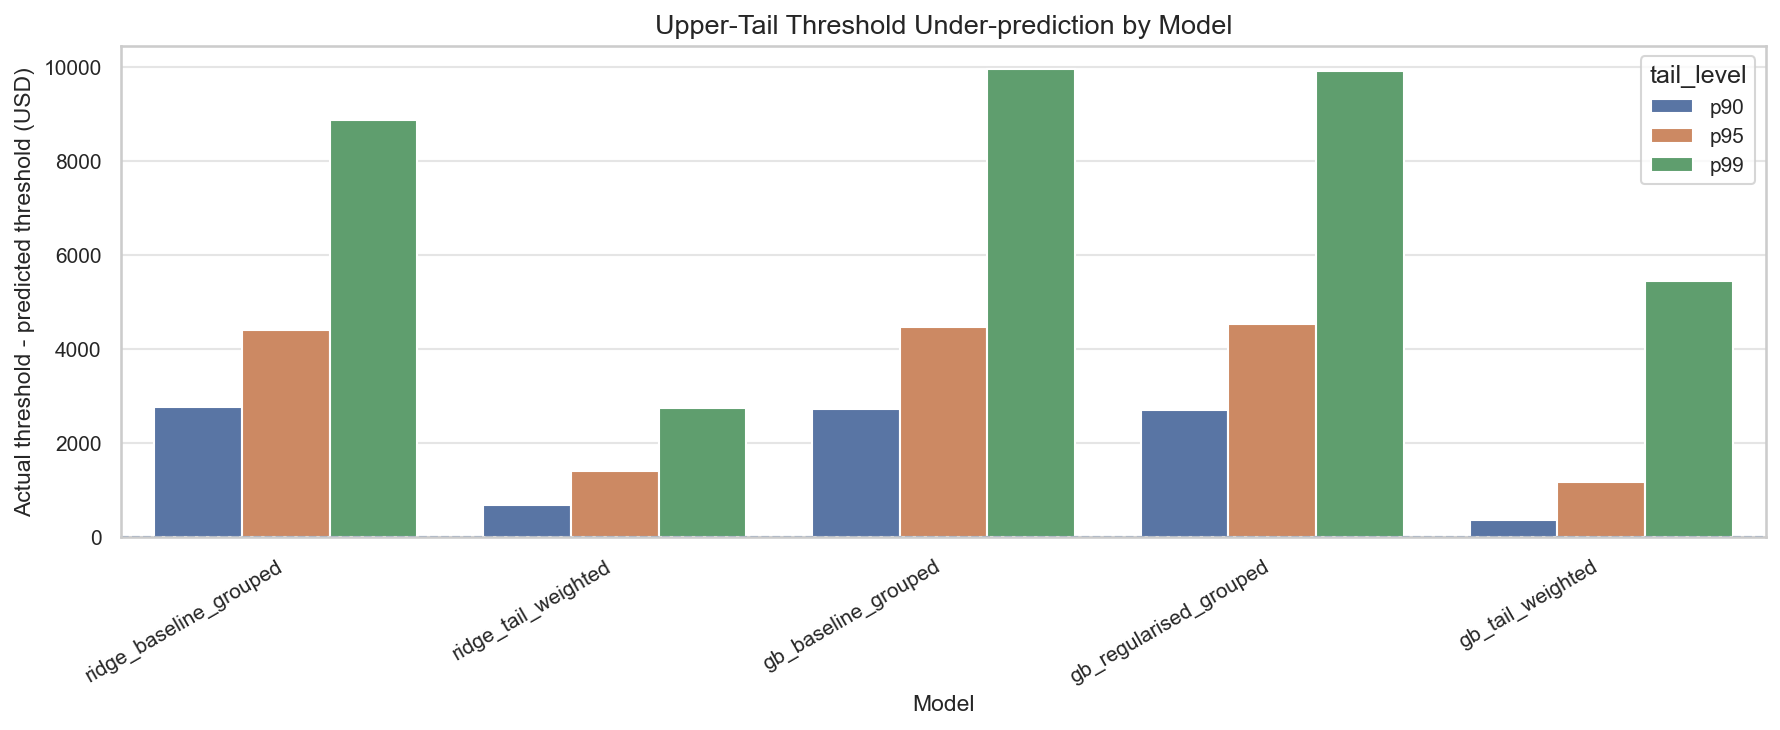

In [17]:
plot_models = [
    "ridge_baseline_grouped",
    "ridge_tail_weighted",
    "gb_baseline_grouped",
    "gb_regularised_grouped",
    "gb_tail_weighted",
]

plot_tail_detail = tail_metric_detail_df[
    (tail_metric_detail_df["model_name"].isin(plot_models))
    & (tail_metric_detail_df["tail_level"].isin(["p90", "p95", "p99"]))
    ].copy()

fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

sns.barplot(
    data=plot_tail_detail,
    x="model_name",
    y="threshold_underprediction",
    hue="tail_level",
    ax=ax,
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Upper-Tail Threshold Under-prediction by Model")
ax.set_xlabel("Model")
ax.set_ylabel("Actual threshold - predicted threshold (USD)")

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
)

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_08_tail_threshold_underprediction_by_model",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Figures\fig_08_tvar_underprediction_by_model.png


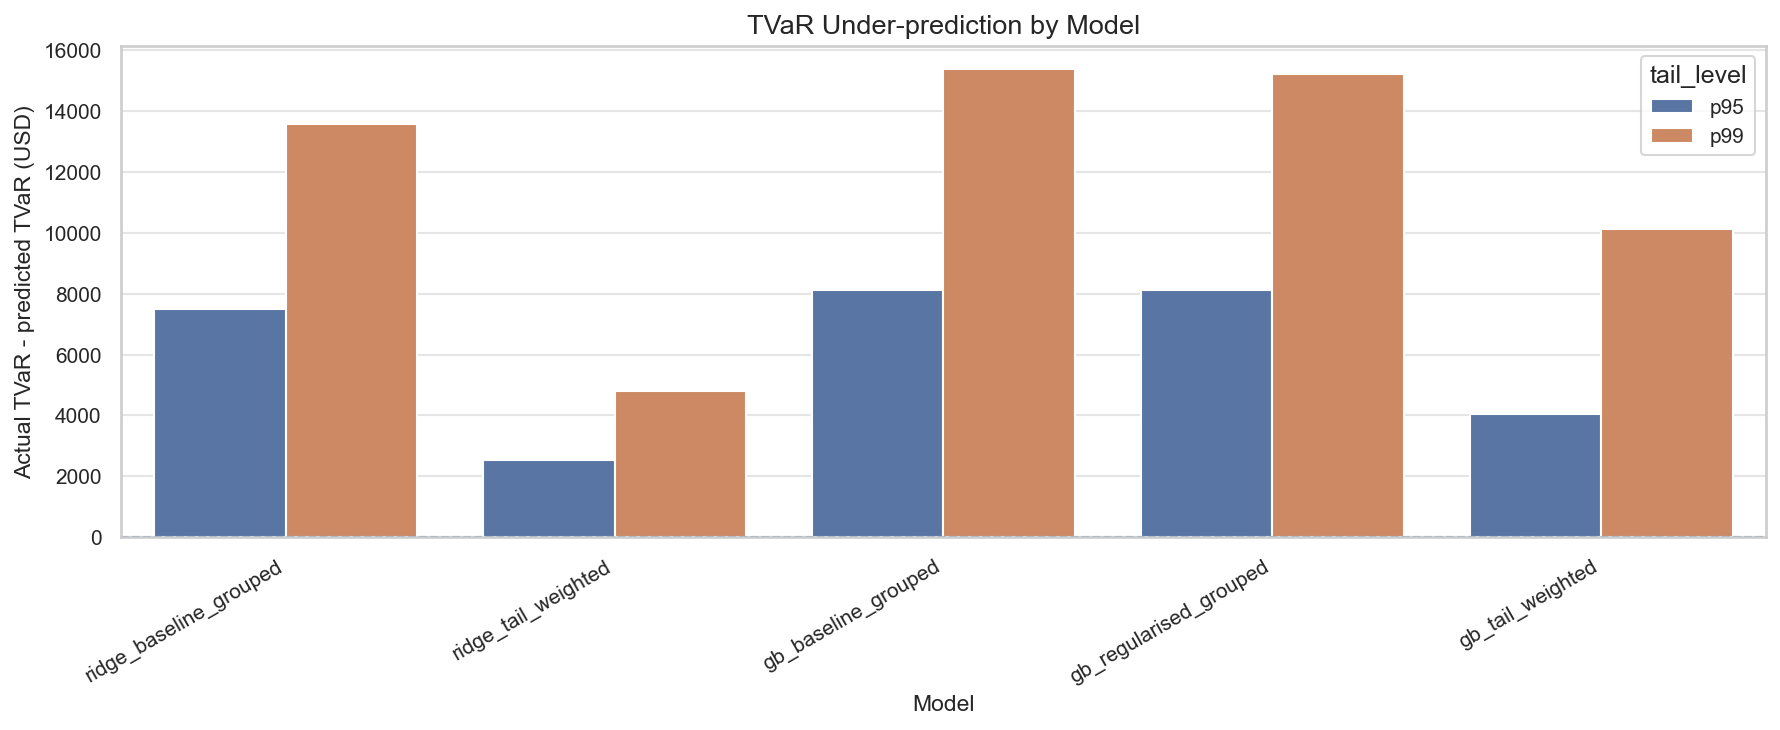

In [18]:
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

sns.barplot(
    data=plot_tail_detail[plot_tail_detail["tail_level"].isin(["p95", "p99"])],
    x="model_name",
    y="distribution_tvar_underprediction",
    hue="tail_level",
    ax=ax,
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("TVaR Under-prediction by Model")
ax.set_xlabel("Model")
ax.set_ylabel("Actual TVaR - predicted TVaR (USD)")

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
)

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_08_tvar_underprediction_by_model",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics\Figures\fig_08_quantile_calibration.png


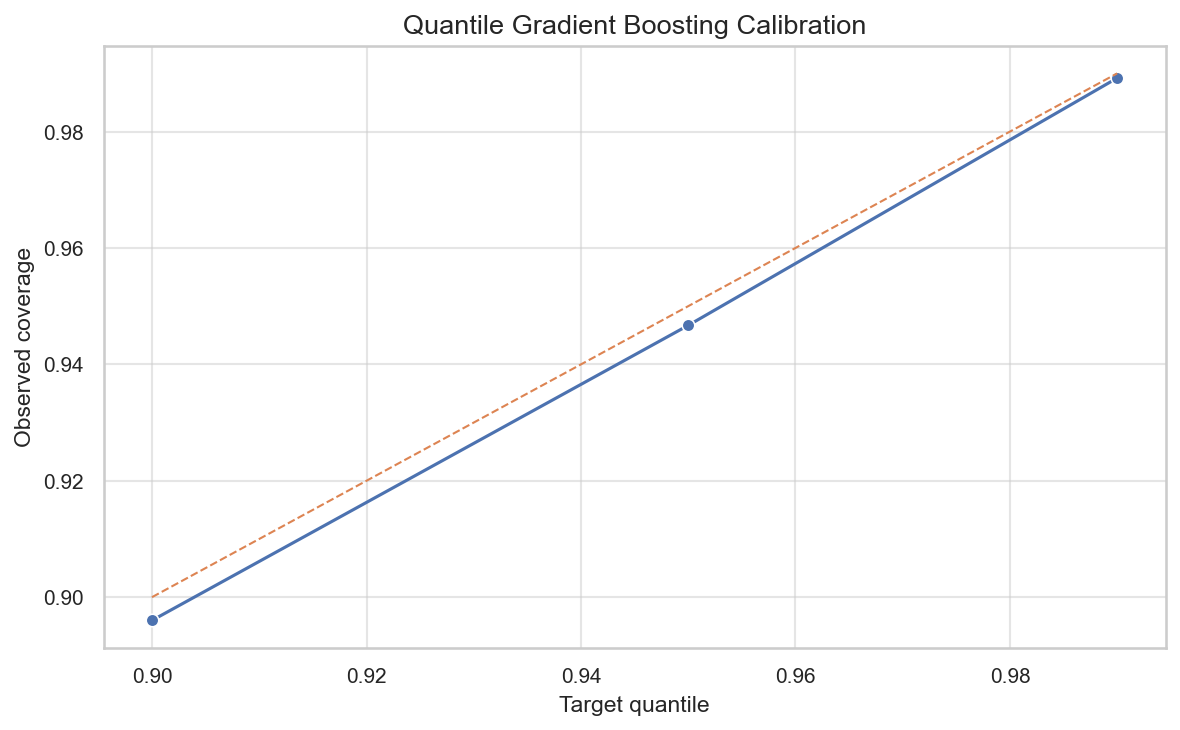

In [19]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

sns.lineplot(
    data=quantile_calibration_df,
    x="target_quantile",
    y="observed_coverage",
    marker="o",
    ax=ax,
)

ax.plot(
    [0.90, 0.99],
    [0.90, 0.99],
    linestyle="--",
    linewidth=1,
)

ax.set_title("Quantile Gradient Boosting Calibration")
ax.set_xlabel("Target quantile")
ax.set_ylabel("Observed coverage")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_08_quantile_calibration",
)

plt.show()